In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
df = pd.read_csv('ushape.csv')

In [3]:
df.head()

,X,Y,class
0,0.031595,0.986988,0.0
1,2.115098,-0.046244,1.0
2,0.882490,-0.075756,0.0
3,-0.055144,-0.037332,1.0
4,0.829545,-0.539321,1.0


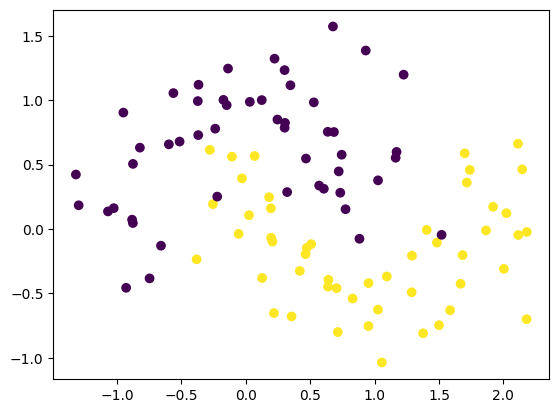

In [4]:
plt.scatter(df['X'],df['Y'],c=df['class'])

In [5]:
X = df.iloc[:,0:2].values
y = df.iloc[:,-1].values

In [6]:
import tensorflow
from tensorflow import keras
from keras import Sequential
from keras.layers import Dense

c:\Program Files\Python313\Lib\site-packages\keras\src\export\tf2onnx_lib.py:8: FutureWarning: In the future `np.object` will be defined as the corresponding NumPy scalar.
  if not hasattr(np, "object"):


In [7]:
model = Sequential()

model.add(Dense(10,activation='relu',input_dim=2,kernel_initializer='he_normal'))
model.add(Dense(10,activation='relu',kernel_initializer='he_normal'))
model.add(Dense(10,activation='relu',kernel_initializer='he_normal'))
model.add(Dense(10,activation='relu',kernel_initializer='he_normal'))
model.add(Dense(1,activation='sigmoid'))

model.summary()

c:\Program Files\Python313\Lib\site-packages\keras\src\layers\core\dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 10)             │            30 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │           110 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 10)             │           110 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 10)             │           110 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 1)              │            11 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 371 (1.45 KB)

 Trainable params: 371 (1.45 KB)

 Non-trainable params: 0 (0.00 B)

In [8]:
model.get_weights()

[array([[ 0.5372033 ,  0.82879305,  1.9562507 , -2.2204556 ,  0.7633311 ,
          2.2326498 ,  0.64627224,  0.47754937, -0.08459977, -1.130855  ],
        [ 0.35522074, -0.3841828 ,  0.9901718 , -1.820466  , -0.8440393 ,
         -1.7355652 ,  0.42813513,  1.103408  , -1.9013891 , -0.05861007]],
       dtype=float32),
 array([0., 0., 0., 0., 0., 0., 0., 0., 0., 0.], dtype=float32),
 array([[-0.03272241,  0.30540815,  0.58313036,  0.18561524,  0.22784047,
          0.95851284,  0.15054624, -0.07019261,  0.1124077 ,  0.10585517],
        [ 0.55050176, -0.46174496, -0.35479432,  0.38504675, -0.11830094,
          0.8380635 , -0.13420598,  0.1526261 ,  0.18323919,  0.3207929 ],
        [ 0.17319278,  0.02973039,  0.3746031 ,  0.9159937 ,  0.16775079,
          0.09585259, -0.29088268, -0.43405893, -0.19661489, -0.5051965 ],
        [-0.24195355, -0.07643487, -0.46779704, -0.11153017, -0.3353638 ,
         -0.43615118, -0.24266508,  0.04755691, -0.8730105 , -0.16402557],
        [-0.27492

In [9]:
model.compile(loss='binary_crossentropy',optimizer='adam',metrics=['accuracy'])

In [10]:
history = model.fit(X,y,epochs=100,validation_split=0.2)

Epoch 1/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 4s 385ms/step - accuracy: 0.5000 - loss: 0.8288 - val_accuracy: 0.5000 - val_loss: 0.6553
Epoch 2/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 71ms/step - accuracy: 0.4875 - loss: 0.8036 - val_accuracy: 0.5000 - val_loss: 0.6374
Epoch 3/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 60ms/step - accuracy: 0.4750 - loss: 0.7779 - val_accuracy: 0.5000 - val_loss: 0.6211
Epoch 4/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 61ms/step - accuracy: 0.4750 - loss: 0.7540 - val_accuracy: 0.5000 - val_loss: 0.6066
Epoch 5/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step - accuracy: 0.5125 - loss: 0.7316 - val_accuracy: 0.5500 - val_loss: 0.5929
Epoch 6/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 51ms/step - accuracy: 0.5250 - loss: 0.7115 - val_accuracy: 0.6500 - val_loss: 0.5798
Epoch 7/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 73ms/step - accuracy: 0.5250 - loss: 0.6910 - val_accuracy: 0.6500 - val_loss: 0.5677
Epoch 8/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 93ms/step - accuracy: 0.5250 - loss: 0.6722 - val_accuracy: 0.6500 - val_loss